In [63]:
import pandas as pd
import seaborn as sns

In [64]:
df=pd.read_csv("smartcart_customers.csv")

In [65]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [66]:
df.shape

(2240, 22)

In [67]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

<Axes: ylabel='Income'>

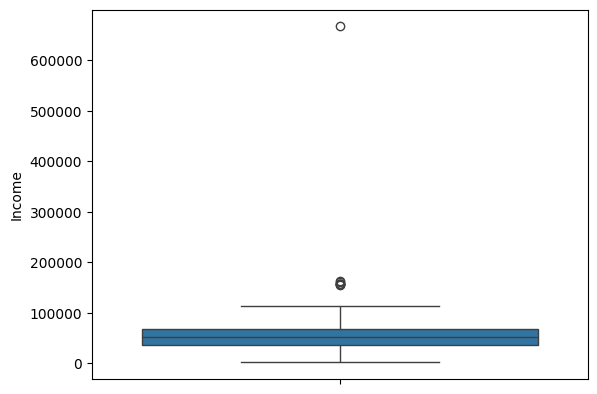

In [68]:
sns.boxplot(df['Income'])

In [69]:
q1=df.describe()['Income']['25%']
q3=df.describe()['Income']['75%']

In [70]:
IQR=q3-q1

In [71]:
upper_limit=q1-1.5*IQR
lower_limit=q3+1.5*IQR

In [72]:
df['Income']=df['Income'].clip(upper_limit,lower_limit)

In [73]:
df['Income']=df['Income'].fillna(df['Income'].median())

In [74]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [75]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [76]:
df['Age']=2026-df['Year_Birth']

In [77]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date=df['Dt_Customer'].max()
df['Customer_tenure_Days']=(reference_date-df['Dt_Customer']).dt.days

In [78]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312


In [79]:
df['Total Spending']=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [80]:
df['Total Childrens']=df['Kidhome']+df['Teenhome']

In [81]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total Spending,Total Childrens
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [82]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [83]:
df['Education']=df['Education'].replace({
    'Basic':'UnderGraduate',
    '2n Cycle2n Cycle':'UnderGraduate',
    'Graduation':'Graduate',
    'Master':'PostGraduate',
    'PhD':'PostGraduate'
}
                                       )

In [84]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [85]:
df['Living with']=df['Marital_Status'].replace({
    'Married':'Partner','Together':'Partner',
    'Single':'Alone','Divorced':'Alone',
    'Widow':'Alone','Absurd':'Alone','YOLO':'Alone'
}
                                              )

In [86]:
df['Living with'].value_counts()

Living with
Partner    1444
Alone       796
Name: count, dtype: int64

In [87]:
df=df.drop(columns=['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds'])

In [88]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total Spending,Total Childrens,Living with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [89]:
df.shape

(2240, 15)

In [90]:
df.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total Spending,Total Childrens,Living with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


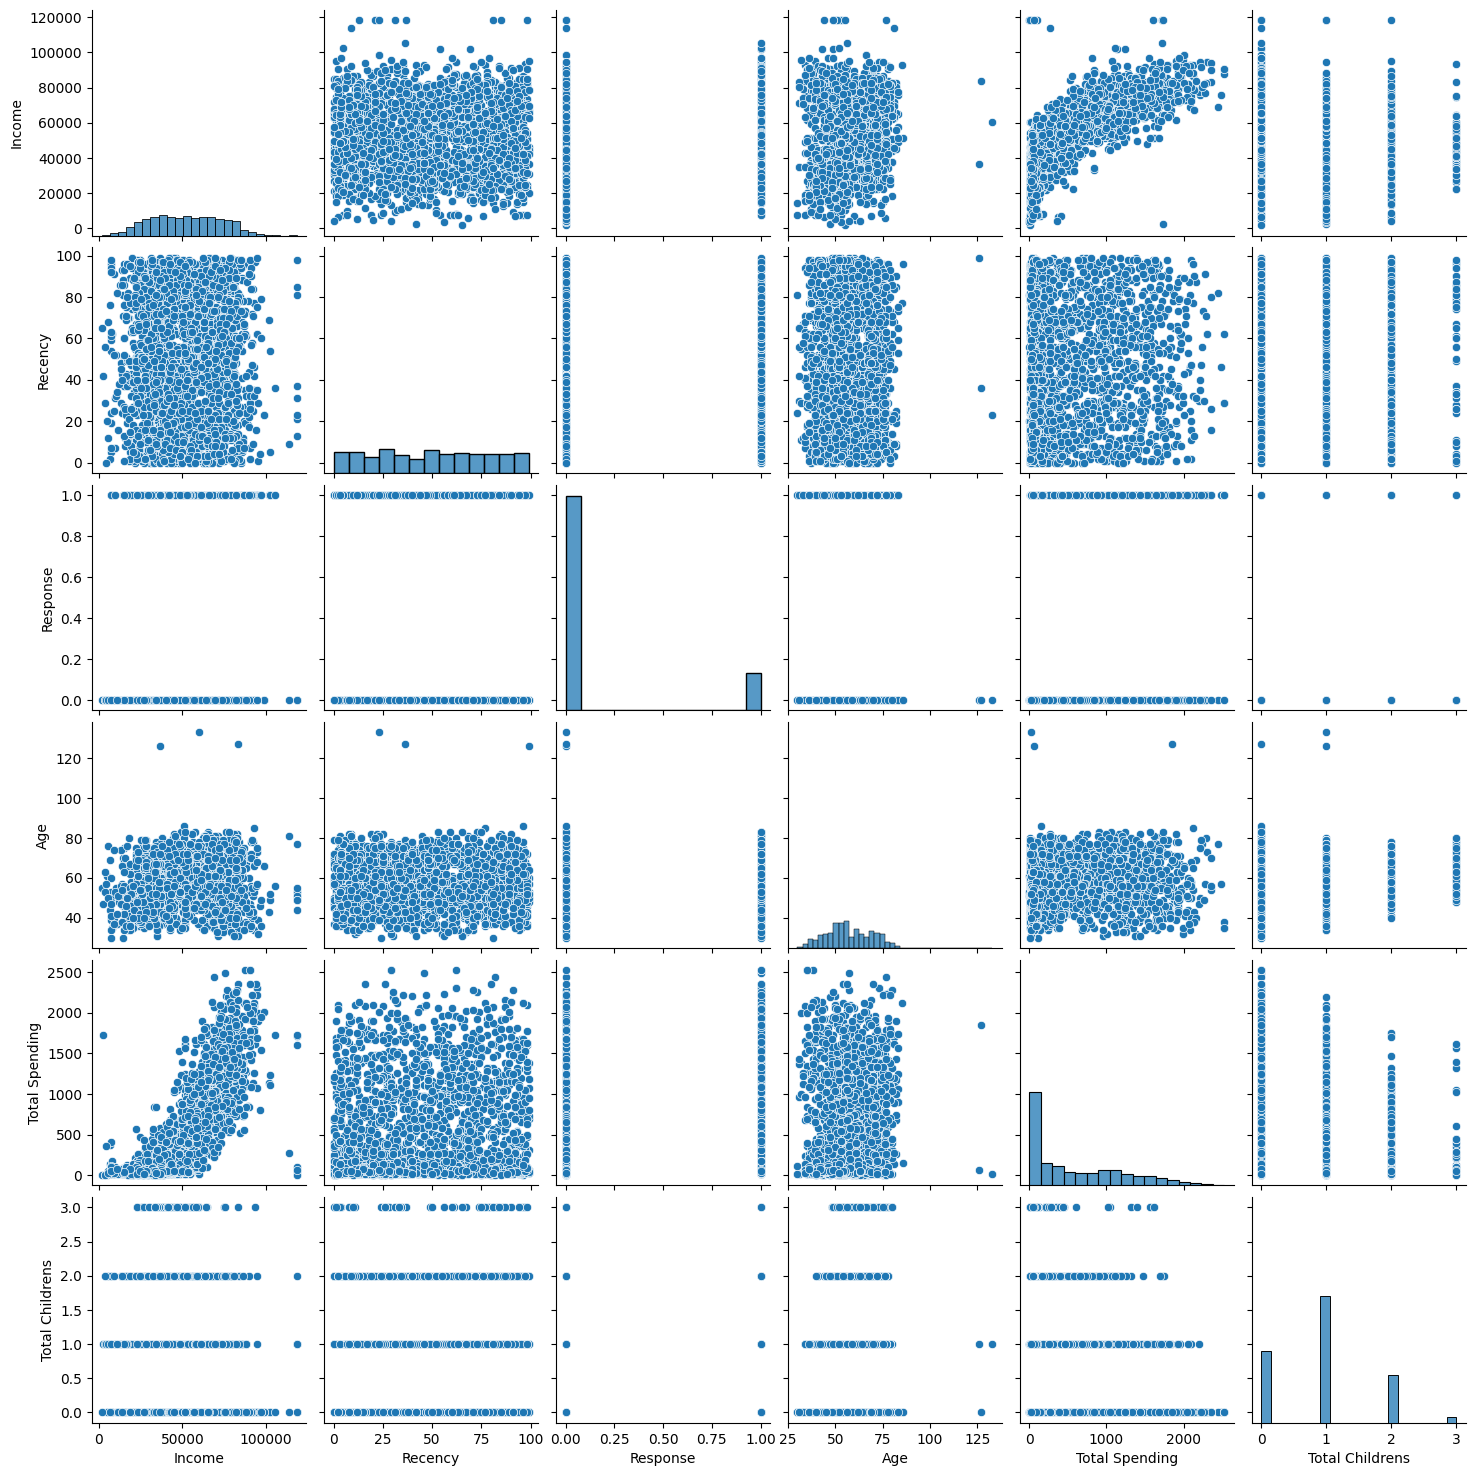

In [91]:
cols=['Income','Recency','Response','Age','Total Spending','Total Childrens']
sns.pairplot(df[cols])

In [92]:
df=df[(df['Age']<90)]

In [93]:
corr_matrix=df.corr(numeric_only=True)

<Axes: >

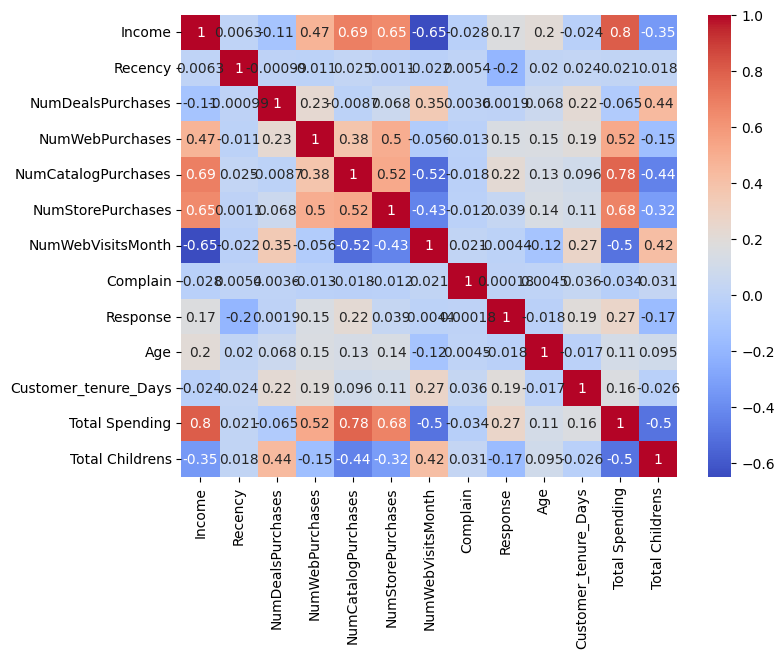

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
    )

In [95]:
from sklearn.preprocessing import OneHotEncoder

In [96]:
OHE=OneHotEncoder()

In [97]:
cat_col=['Education','Living with']
encoded_col=OHE.fit_transform(df[cat_col])


In [98]:
enc_df = pd.DataFrame(
    encoded_col.toarray(),
    columns=OHE.get_feature_names_out(cat_col),
    index=df.index
)

In [99]:
df = pd.concat([df.drop(columns=cat_col), enc_df], axis=1)

In [100]:
df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_Days,Total Spending,Total Childrens,Education_2n Cycle,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living with_Alone,Living with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,0.0,1.0


In [101]:
df.shape

(2237, 19)

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
X=df

In [104]:
scaler=StandardScaler()

In [105]:
X_scaled=scaler.fit_transform(X)

In [106]:
X_scaled

array([[ 0.29986762,  0.30727179,  0.34837058, ..., -0.15727874,
         1.3481025 , -1.3481025 ],
       [-0.26330476, -0.38358403, -0.16909621, ..., -0.15727874,
         1.3481025 , -1.3481025 ],
       [ 0.94330901, -0.79809753, -0.686563  , ..., -0.15727874,
        -0.74178336,  0.74178336],
       ...,
       [ 0.24462   ,  1.44718391, -0.686563  , ..., -0.15727874,
         1.3481025 , -1.3481025 ],
       [ 0.83023523, -1.41986777, -0.16909621, ..., -0.15727874,
        -0.74178336,  0.74178336],
       [ 0.0482689 , -0.31449845,  0.34837058, ..., -0.15727874,
        -0.74178336,  0.74178336]], shape=(2237, 19))

In [107]:
from sklearn.decomposition import PCA

In [108]:
pca=PCA(
    n_components=3
)
X_pca=pca.fit_transform(X_scaled)

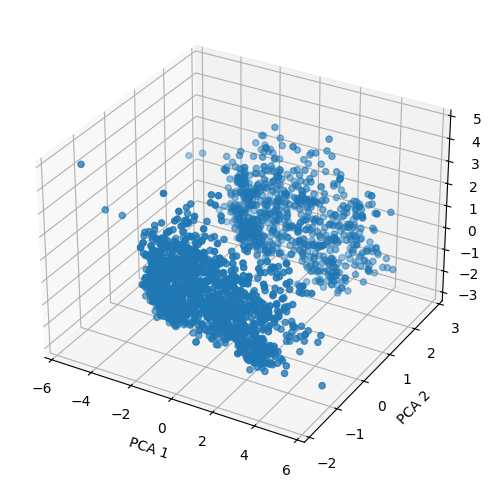

In [109]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2]
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

plt.show()

In [110]:
pca.explained_variance_ratio_

array([0.22138735, 0.10796255, 0.09863964])

In [111]:
#Analyzing K vale-Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [112]:
wcss=[]
for k in range(1,11):
    kmens=KMeans(
        n_clusters=k,
        random_state=42
    )


In [113]:
kmens.fit_predict(X_pca)

wcss.append(kmens.inertia_)

In [114]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Apply KneeLocator
knee = KneeLocator(
    range(1, 11),
    wcss,
    curve='convex',
    direction='decreasing'
)

optimal_k = knee.elbow
print("Optimal K:", optimal_k)

Optimal K: 3


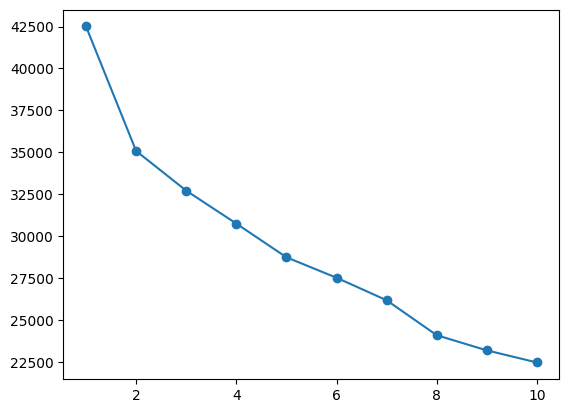

In [115]:
plt.plot(range(1,11),wcss,marker='o')

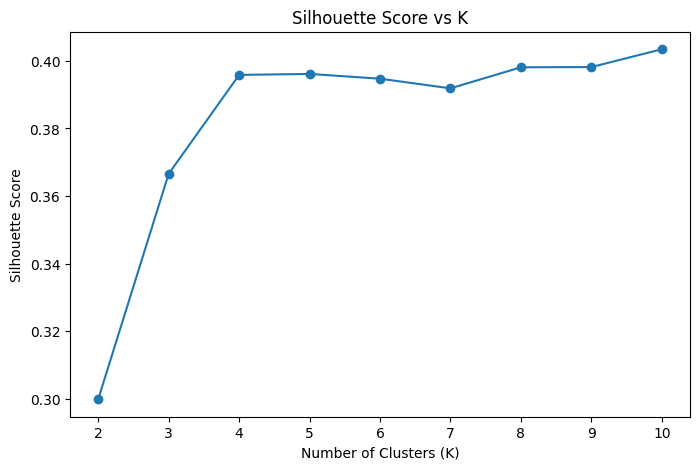

In [116]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Now plot
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

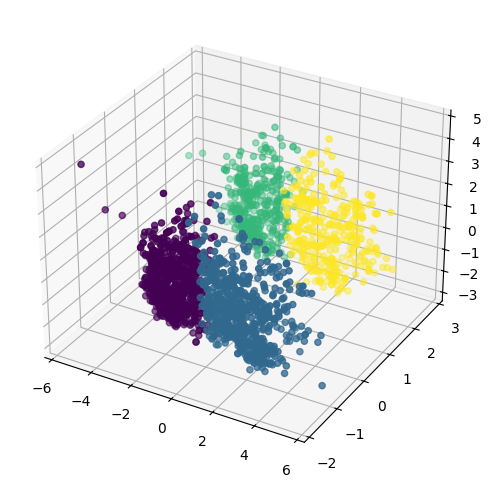

In [117]:
#Clustering  1.Kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
label_kmeans=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label_kmeans)

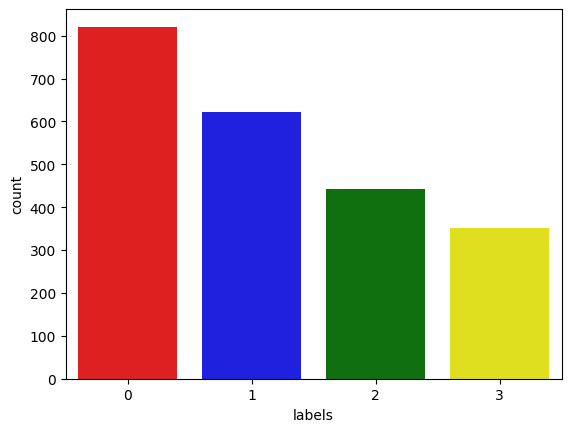

In [118]:
df['labels']=label_kmeans
pal = ['red', 'blue', 'green', 'yellow']

cluster=sns.countplot(x='labels', data=df, palette=pal, hue='labels', legend=False)

<Axes: xlabel='Total Spending', ylabel='Income'>

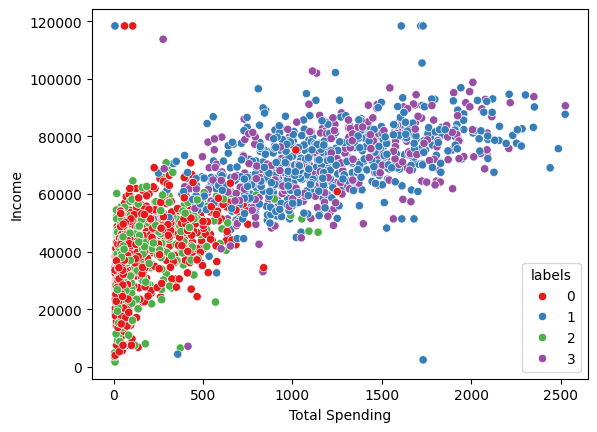

In [119]:
sns.scatterplot(
    x='Total Spending',
    y='Income',
    hue='labels',
    data=df,
    palette='Set1'
)

In [120]:
df['cluster'] = kmeans.labels_
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        37567.694884  49.214373           2.543240         2.861145   
1        70482.750804  48.766881           2.131833         5.700965   
2        37244.498871  48.232506           2.566591         2.740406   
3        70723.696581  50.547009           1.863248         5.794872   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.771011           3.744214           6.529842  0.009744   
1                   5.114148           8.527331           3.736334  0.008039   
2                   0.846501           3.654628           6.577878  0.011287   
3                   5.034188           8.447293           3.703704  0.005698   

         Response        Age  Customer_tenure_Days  Total Spending  \
cluster         

In [121]:
import gradio as gr
import numpy as np
import pandas as pd

# ===============================
# Prediction Function
# ===============================
def predict_cluster(
    Income, Recency, NumDealsPurchases,
    NumWebPurchases, NumCatalogPurchases,
    NumStorePurchases, NumWebVisitsMonth,
    Complain, Response, Age,
    Customer_tenure_Days, Total_Spending,
    Total_Childrens,
    Education, Living_with
):
    
    # Create DataFrame
    input_df = pd.DataFrame([{
        "Income": Income,
        "Recency": Recency,
        "NumDealsPurchases": NumDealsPurchases,
        "NumWebPurchases": NumWebPurchases,
        "NumCatalogPurchases": NumCatalogPurchases,
        "NumStorePurchases": NumStorePurchases,
        "NumWebVisitsMonth": NumWebVisitsMonth,
        "Complain": Complain,
        "Response": Response,
        "Age": Age,
        "Customer_tenure_Days": Customer_tenure_Days,
        "Total Spending": Total_Spending,
        "Total Childrens": Total_Childrens,
        "Education": Education,
        "Living with": Living_with
    }])
    
    # One Hot Encode
    encoded = OHE.transform(input_df[cat_col])
    encoded_df = pd.DataFrame(
        encoded.toarray(),
        columns=OHE.get_feature_names_out(cat_col)
    )
    
    # Drop original categorical
    input_df = input_df.drop(columns=cat_col)
    
    # Combine
    final_df = pd.concat([input_df.reset_index(drop=True), encoded_df], axis=1)
    
    # Scale
    scaled = scaler.transform(final_df)
    
    # PCA
    pca_data = pca.transform(scaled)
    
    # Predict cluster
    cluster = kmeans.predict(pca_data)
    
    return f"Predicted Cluster: {cluster[0]}"


# ===============================
# Gradio Interface
# ===============================
interface = gr.Interface(
    fn=predict_cluster,
    inputs=[
        gr.Number(label="Income"),
        gr.Number(label="Recency"),
        gr.Number(label="NumDealsPurchases"),
        gr.Number(label="NumWebPurchases"),
        gr.Number(label="NumCatalogPurchases"),
        gr.Number(label="NumStorePurchases"),
        gr.Number(label="NumWebVisitsMonth"),
        gr.Number(label="Complain (0/1)"),
        gr.Number(label="Response (0/1)"),
        gr.Number(label="Age"),
        gr.Number(label="Customer Tenure Days"),
        gr.Number(label="Total Spending"),
        gr.Number(label="Total Childrens"),
        gr.Dropdown(["2n Cycle","Graduate","PostGraduate","UnderGraduate"], label="Education"),
        gr.Dropdown(["Alone","Partner"], label="Living with")
    ],
    outputs="text",
    title="Customer Segmentation - KMeans + PCA",
    description="Enter customer details to predict cluster"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
